In [1]:
import torch
import sklearn  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('/gpfs0/bgu-benshimo/users/wavishay/thesis/avishai_work/ASV_utils/')
from ASV_utils.data_loading import load_data_all, load_data_male, load_data_female
from sklearn.decomposition import PCA
from umap import UMAP, ParametricUMAP

/gpfs0/bgu-benshimo/users/wavishay/env/pythn_new/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
class class_time_embeddings_umap:
    def __init__(self,path_to_male_embeddings, path_to_female_embeddings):
        self.path_to_male_embeddings = path_to_male_embeddings
        self.path_to_female_embeddings = path_to_female_embeddings
        
        (embedded_groups_1_1_male, embedded_groups_1_2_male, embedded_groups_1_3_male,
            chosen_labels_1_1_is_spoofed_male, chosen_labels_2_1_is_spoofed_male, chosen_labels_3_1_is_spoofed_male,
            chosen_labels_numeric_1_1_male, chosen_labels_numeric_2_1_male, chosen_labels_numeric_3_1_male,
            chosen_labels_1_1_attack_logical_male, chosen_labels_2_1_attack_logical_male, chosen_labels_3_1_attack_logical_male,
            chosen_labels_1_1_name_male, chosen_labels_2_1_name_male, chosen_labels_3_1_name_male,
            chosen_labels_1_1_speaker_id_male, chosen_labels_2_1_speaker_id_male, chosen_labels_3_1_speaker_id_male,
            chosen_labels_1_1_sex_male, chosen_labels_2_1_sex_male, chosen_labels_3_1_sex_male) = load_data_male(self.path_to_male_embeddings)

        (embedded_groups_1_1_female, embedded_groups_1_2_female, embedded_groups_1_3_female,
            chosen_labels_1_1_is_spoofed_female, chosen_labels_2_1_is_spoofed_female, chosen_labels_3_1_is_spoofed_female,
            chosen_labels_numeric_1_1_female, chosen_labels_numeric_2_1_female, chosen_labels_numeric_3_1_female,
            chosen_labels_1_1_attack_logical_female, chosen_labels_2_1_attack_logical_female, chosen_labels_3_1_attack_logical_female,
            chosen_labels_1_1_name_female, chosen_labels_2_1_name_female, chosen_labels_3_1_name_female,
            chosen_labels_1_1_speaker_id_female, chosen_labels_2_1_speaker_id_female, chosen_labels_3_1_speaker_id_female,
            chosen_labels_1_1_sex_female, chosen_labels_2_1_sex_female, chosen_labels_3_1_sex_female) = load_data_female(self.path_to_female_embeddings)

        # Stack male and female data
        self.embedded_groups_1_1 = np.vstack((embedded_groups_1_1_male, embedded_groups_1_1_female))
        self.embedded_groups_1_2 = np.vstack((embedded_groups_1_2_male, embedded_groups_1_2_female))
        self.embedded_groups_1_3 = np.vstack((embedded_groups_1_3_male, embedded_groups_1_3_female))

        self.chosen_labels_1_1_is_spoofed = np.hstack((chosen_labels_1_1_is_spoofed_male, chosen_labels_1_1_is_spoofed_female))
        self.chosen_labels_2_1_is_spoofed = np.hstack((chosen_labels_2_1_is_spoofed_male, chosen_labels_2_1_is_spoofed_female))
        self.chosen_labels_3_1_is_spoofed = np.hstack((chosen_labels_3_1_is_spoofed_male, chosen_labels_3_1_is_spoofed_female))

        self.chosen_labels_numeric_1_1 = np.hstack((chosen_labels_numeric_1_1_male, chosen_labels_numeric_1_1_female))
        self.chosen_labels_numeric_2_1 = np.hstack((chosen_labels_numeric_2_1_male, chosen_labels_numeric_2_1_female))
        self.chosen_labels_numeric_3_1 = np.hstack((chosen_labels_numeric_3_1_male, chosen_labels_numeric_3_1_female))

        self.chosen_labels_1_1_attack_logical = pd.concat([pd.Series(chosen_labels_1_1_attack_logical_male),
                                                           pd.Series(chosen_labels_1_1_attack_logical_female)])
        self.chosen_labels_2_1_attack_logical = pd.concat([pd.Series(chosen_labels_2_1_attack_logical_male),
                                                           pd.Series(chosen_labels_2_1_attack_logical_female)])
        self.chosen_labels_3_1_attack_logical = pd.concat([pd.Series(chosen_labels_3_1_attack_logical_male),
                                                           pd.Series(chosen_labels_3_1_attack_logical_female)])

        self.chosen_labels_1_1_name = np.hstack((chosen_labels_1_1_name_male, chosen_labels_1_1_name_female))
        self.chosen_labels_2_1_name = np.hstack((chosen_labels_2_1_name_male, chosen_labels_2_1_name_female))
        self.chosen_labels_3_1_name = np.hstack((chosen_labels_3_1_name_male, chosen_labels_3_1_name_female))

        self.chosen_labels_1_1_speaker_id = np.hstack((chosen_labels_1_1_speaker_id_male, chosen_labels_1_1_speaker_id_female))
        self.chosen_labels_2_1_speaker_id = np.hstack((chosen_labels_2_1_speaker_id_male, chosen_labels_2_1_speaker_id_female))
        self.chosen_labels_3_1_speaker_id = np.hstack((chosen_labels_3_1_speaker_id_male, chosen_labels_3_1_speaker_id_female))

        self.chosen_labels_1_1_sex = pd.concat([pd.Series(chosen_labels_1_1_sex_male), pd.Series(chosen_labels_1_1_sex_female)])
        self.chosen_labels_2_1_sex = pd.concat([pd.Series(chosen_labels_2_1_sex_male), pd.Series(chosen_labels_2_1_sex_female)])
        self.chosen_labels_3_1_sex = pd.concat([pd.Series(chosen_labels_3_1_sex_male), pd.Series(chosen_labels_3_1_sex_female)])
        
        
        self.train_embedding_pca = None
        self.dev_embedding_pca = None
        self.train_embedding_umap = None
        self.dev_embedding_umap = None
        
        self.chosen_labels_1_1_attack_logical = pd.Series([x[0] for x in self.chosen_labels_1_1_attack_logical]).replace('none', 'Genuine')
        
        self.chosen_labels_2_1_attack_logical = pd.Series([x[0] for x in self.chosen_labels_2_1_attack_logical]).replace('none', 'Genuine')
        
        self.chosen_labels_3_1_attack_logical = pd.Series([x[0] for x in self.chosen_labels_3_1_attack_logical]).replace('none', 'Genuine')
        
        self.chosen_labels_1_1_sex = pd.Series([x[0] for x in self.chosen_labels_1_1_sex])
        
        self.chosen_labels_2_1_sex = pd.Series([x[0] for x in self.chosen_labels_2_1_sex])
        
        self.chosen_labels_3_1_sex = pd.Series([x[0] for x in self.chosen_labels_3_1_sex])
        
        
        # Define unique labels including 'genuine'
        unique_labels = np.concatenate([self.chosen_labels_1_1_attack_logical.unique() , self.chosen_labels_2_1_attack_logical.unique()], axis=0)
        
        
        # Generate a colormap
         
            
        colors = np.array([
            "#A52A2A",  # Brown
            "#FFD700",  # Gold
            "#2E8B57",  # SeaGreen
            "#800080",  # Purple
            "#FFFF00",  # Yellow
            "#00FF00",  # Green
            "#FF00FF",  # Magenta
            "#800000",  # Maroon
            "#808000",  # Olive
            "#800080",  # Purple
            "#008080",  # Teal
            "#7FFF00",  # Chartreuse
            "#D2691E",  # Chocolate
            "#DC143C",  # Crimson
            "#4B0082",  # Indigo
            "#ADFF2F",  # GreenYellow
            "#FF4500",  # OrangeRed
        ])

        # Ensure uniqueness by removing duplicates (if needed)
        # colors = np.unique(colors, axis=0)

        # Map each unique label to a color
        labels = [f"A{str(i).zfill(2)}" for i in range(1, 20) if i not in [15, 17, 18]]

        # Add the 'none' label
        labels.append('Genuine')

        # Create the dictionary mapping labels to colors
        label_to_color = {label: color for label, color in zip(labels, colors)}

        # Explicitly set 'none' to BLUE color
        label_to_color['Genuine'] = "#0000FF" # Blue
        label_to_color['A18'] = "#00FFFF" # Cyan
        label_to_color['A17'] = "#FF0000" # Red
        label_to_color['A15'] = "#FFA500" # Orange
        

        # Select the keys to extract
        keys_to_extract = ['Genuine', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06']
        selected_colors_A01_A06 = {key: label_to_color[key] for key in keys_to_extract}

        #'A01', 'A02', 'A03', 'A04', 'A05', 'A06',
        keys_to_extract_2 = ['Genuine', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19']
        selected_colors_A01_A19 = {key: label_to_color[key] for key in keys_to_extract_2}

        
        self.label_to_color_1 = selected_colors_A01_A06
        
        self.labels_to_color_3 = selected_colors_A01_A19
        
        
        self.chosen_labels_1_1_attack_logical_mapping = self.chosen_labels_1_1_attack_logical.map(self.label_to_color_1)
       
        self.chosen_labels_2_1_attack_logical_mapping = self.chosen_labels_2_1_attack_logical.map(self.label_to_color_1)
        
        self.chosen_labels_3_1_attack_logical_mapping = self.chosen_labels_3_1_attack_logical.map(self.labels_to_color_3)
        
        self.frontsize = 14
        
    def create_umap(self,include_dev=False,include_eval=False):
        self.umap_train = UMAP(n_components=2,random_state=0)
        self.umap_train.fit(self.embedded_groups_1_1)
        
        if include_dev:
            self.umap_dev = UMAP(n_components=2,random_state=0)
            self.umap_dev.fit(self.embedded_groups_1_2)
        
        if include_eval:
            self.umap_eval = UMAP(n_components=2,random_state=0)
            self.umap_eval.fit(self.embedded_groups_1_3)
        
      
    def plotting_train(self,plot_title='Train embeddings',gender = 'male'):
        
        fig, ax = plt.subplots(figsize=(12, 8))
        
         # Define color mapping for labels 0 and 1
        label_to_color = {0: 'green', 1: 'orange'}
        
        if gender == 'male':
            self.embeddings = self.umap_train.transform(self.embedded_groups_1_1[self.chosen_labels_1_1_sex == 'male'])
        elif gender == 'female':
            self.embeddings = self.umap_train.transform(self.embedded_groups_1_1[self.chosen_labels_1_1_sex == 'female'])
        
        # Convert labels to colors
        color_data = np.array([label_to_color[label] for label in self.chosen_labels_1_1_is_spoofed])
        
        ax.scatter(self.embeddings[:,0],self.embeddings[:,1],c=color_data,alpha = 0.3)
     
            
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for label, color in label_to_color.items()]
        labels = ['Genuine', 'Spoofed']
        # Add legend to the plot
        ax.legend(handles, labels, title="Labels",fontsize=self.frontsize,title_fontsize='14',loc='lower left')
        ax.set_title(plot_title, fontsize=24)
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
   
        plt.show()
    
    def plotting_dev(self,plot_title='Dev embeddings',gender = 'male'):
        fig, ax = plt.subplots(figsize=(12, 8))
        label_to_color = {0: 'purple', 1: 'black'}
        color_data = np.array([label_to_color[label] for label in self.chosen_labels_2_1_is_spoofed])
        if gender == 'male':
            self.embeddings = self.umap_dev.transform(self.embedded_groups_1_2[self.chosen_labels_2_1_sex == 'male'])
        elif gender == 'female':
            self.embeddings = self.umap_dev.transform(self.embedded_groups_1_2[self.chosen_labels_2_1_sex == 'female'])
        
        ax.scatter(self.embeddings[:,0],self.embeddings[:,1],c=color_data,alpha = 0.3)
        
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for label, color in label_to_color.items()]
        labels = ['Genuine', 'Spoofed']
        # Add legend to the plot
        ax.legend(handles, labels, title="Labels",fontsize=self.frontsize,title_fontsize='14',loc='lower left')
        ax.set_title(plot_title, fontsize=24)
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        plt.show()
        
    def plotting_eval(self,plot_title='Eval embeddings',gender = 'male'):
        fig, ax = plt.subplots(figsize=(12, 8))
        label_to_color = {0: 'blue', 1: 'red'}
        color_data = np.array([label_to_color[label] for label in self.chosen_labels_3_1_is_spoofed])
        if gender == 'male':
            self.embeddings = self.umap_eval.transform(self.embedded_groups_1_3[self.chosen_labels_3_1_sex == 'male'])
        elif gender == 'female':
            self.embeddings = self.umap_eval.transform(self.embedded_groups_1_3[self.chosen_labels_3_1_sex == 'female'])
        
        ax.scatter(self.embeddings[:,0],self.embeddings[:,1],c=color_data,alpha = 0.3)
        
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for label, color in label_to_color.items()]
        labels = ['Genuine', 'Spoofed']
        # Add legend to the plot
        ax.legend(handles, labels, title="Labels",fontsize=self.frontsize,title_fontsize='16',loc='lower left')
        ax.set_title(plot_title, fontsize=24)
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        plt.show()
        
    def plotting_vs_attacks_train(self,plot_title='Train embeddings',gender = 'male'):
        fig, ax = plt.subplots(figsize=(12, 8))
        
        if gender == 'male':
            self.embeddings = self.umap_train.transform(self.embedded_groups_1_1[self.chosen_labels_1_1_sex == 'male'])
            ax.scatter(self.embeddings[:,0],self.embeddings[:,1],c=self.chosen_labels_1_1_attack_logical_mapping[self.chosen_labels_1_1_sex == 'male'], alpha=0.3)
        elif gender == 'female':
            self.embeddings = self.umap_train.transform(self.embedded_groups_1_1[self.chosen_labels_1_1_sex == 'female'])
            ax.scatter(self.embeddings[:,0],self.embeddings[:,1],c=self.chosen_labels_1_1_attack_logical_mapping[self.chosen_labels_1_1_sex == 'female'], alpha=0.3)
    
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for label, color in self.label_to_color_1.items()]
        labels = list(self.label_to_color_1.keys())
      
        ax.legend(handles, labels, title="Labels",fontsize=self.frontsize,title_fontsize='14',loc='lower left')
        ax.set_title(plot_title, fontsize=24)
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        plt.show()
        
    def plotting_vs_attacks_dev(self,plot_title='Dev embeddings',gender = 'male'):
        fig, ax = plt.subplots(figsize=(12, 8))
        if gender == 'male':
            self.embeddings = self.umap_dev.transform(self.embedded_groups_1_2[self.chosen_labels_2_1_sex == 'male'])
            ax.scatter(self.embeddings[:,0],self.embeddings[:,1],c=self.chosen_labels_2_1_attack_logical_mapping[self.chosen_labels_2_1_sex == 'male'], alpha=0.3)
        elif gender == 'female':
            self.embeddings = self.umap_dev.transform(self.embedded_groups_1_2[self.chosen_labels_2_1_sex == 'female'])
            ax.scatter(self.embeddings[:,0],self.embeddings[:,1],c=self.chosen_labels_2_1_attack_logical_mapping[self.chosen_labels_2_1_sex == 'female'], alpha=0.3)
    
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for label, color in self.label_to_color_1.items()]
        labels = list(self.label_to_color_1.keys())
        ax.legend(handles, labels, title="Labels",fontsize=self.frontsize,title_fontsize='14',loc='lower left')
        ax.set_title(plot_title, fontsize=24)
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        plt.show()
        
    def plotting_vs_attacks_eval(self,plot_title='Eval embeddings',gender = 'male'):
        fig, ax = plt.subplots(figsize=(12, 8))
        if gender == 'male':
            self.embeddings = self.umap_eval.transform(self.embedded_groups_1_3[self.chosen_labels_3_1_sex == 'male'])
            ax.scatter(self.embeddings[:,0],self.embeddings[:,1],c=self.chosen_labels_3_1_attack_logical_mapping[self.chosen_labels_3_1_sex == 'male'], alpha=0.3)
        elif gender == 'female':
            self.embeddings = self.umap_eval.transform(self.embedded_groups_1_3[self.chosen_labels_3_1_sex == 'female'])
            ax.scatter(self.embeddings[:,0],self.embeddings[:,1],c=self.chosen_labels_3_1_attack_logical_mapping[self.chosen_labels_3_1_sex == 'female'], alpha=0.3)
    
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for label, color in self.labels_to_color_3.items()]
        labels = list(self.labels_to_color_3.keys())
 
        ax.legend(handles, labels, title="Labels",fontsize=self.frontsize,title_fontsize='14',loc='lower left')
        ax.set_title(plot_title, fontsize=24)
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        plt.show()
       
        

    
time_emb = class_time_embeddings_umap('./Data/pmf_both/not_normalize/male','./Data/pmf_both/not_normalize/female')


In [8]:
time_emb.create_umap(include_dev=True,include_eval=True)  

/gpfs0/bgu-benshimo/users/wavishay/env/pythn_new/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/gpfs0/bgu-benshimo/users/wavishay/env/pythn_new/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/gpfs0/bgu-benshimo/users/wavishay/env/pythn_new/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


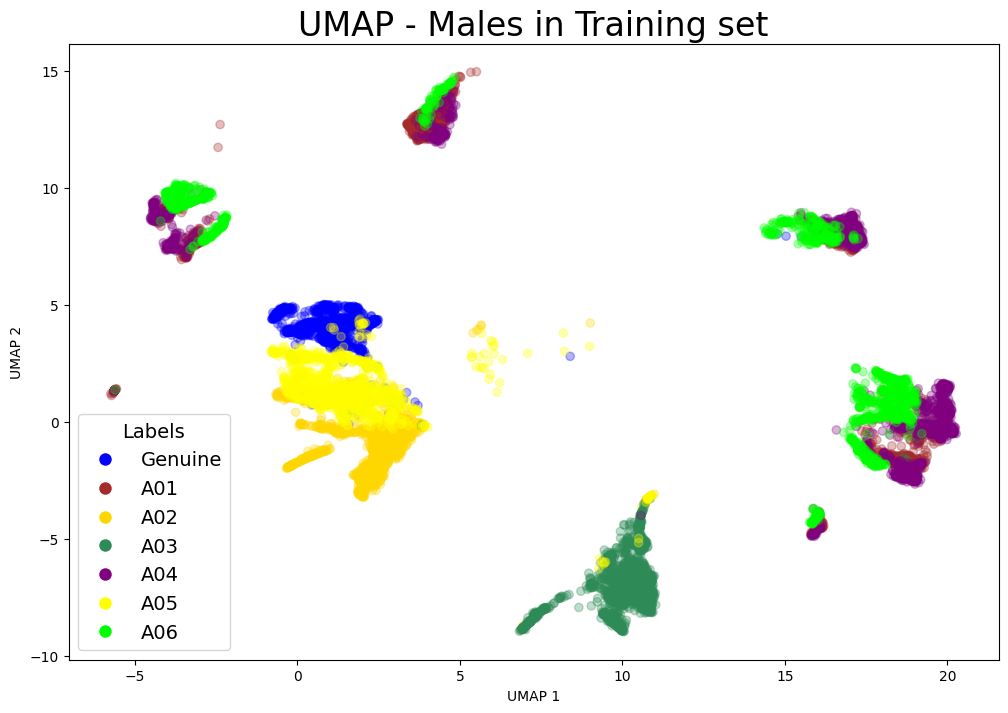

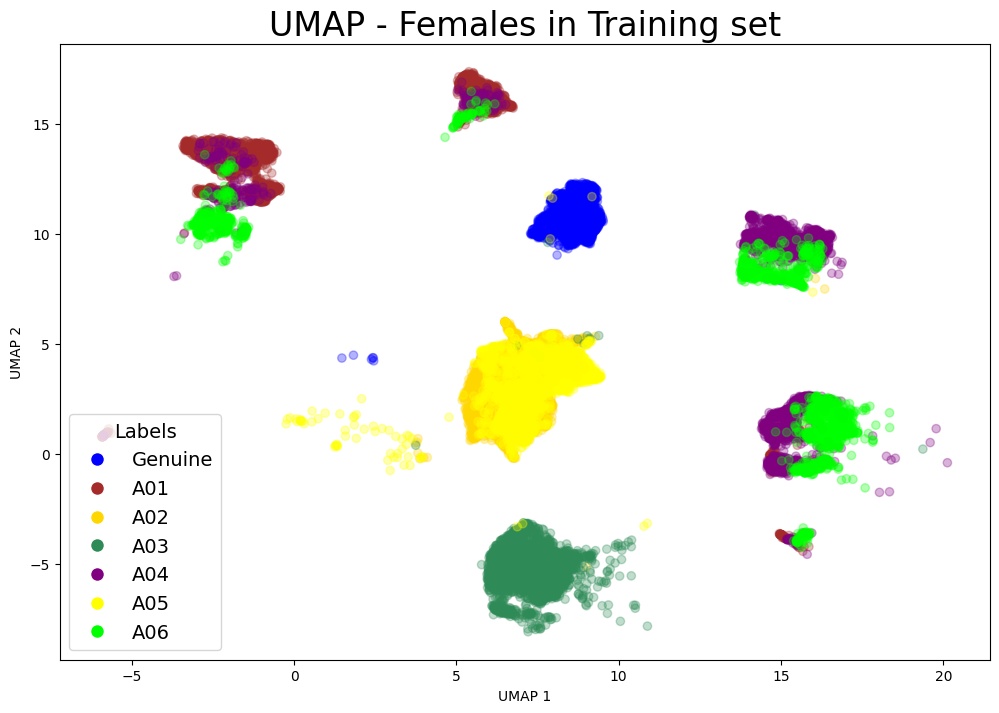

In [9]:
time_emb.plotting_vs_attacks_train(plot_title = 'UMAP - Males in Training set',gender = 'male')
time_emb.plotting_vs_attacks_train(plot_title = 'UMAP - Females in Training set',gender = 'female')

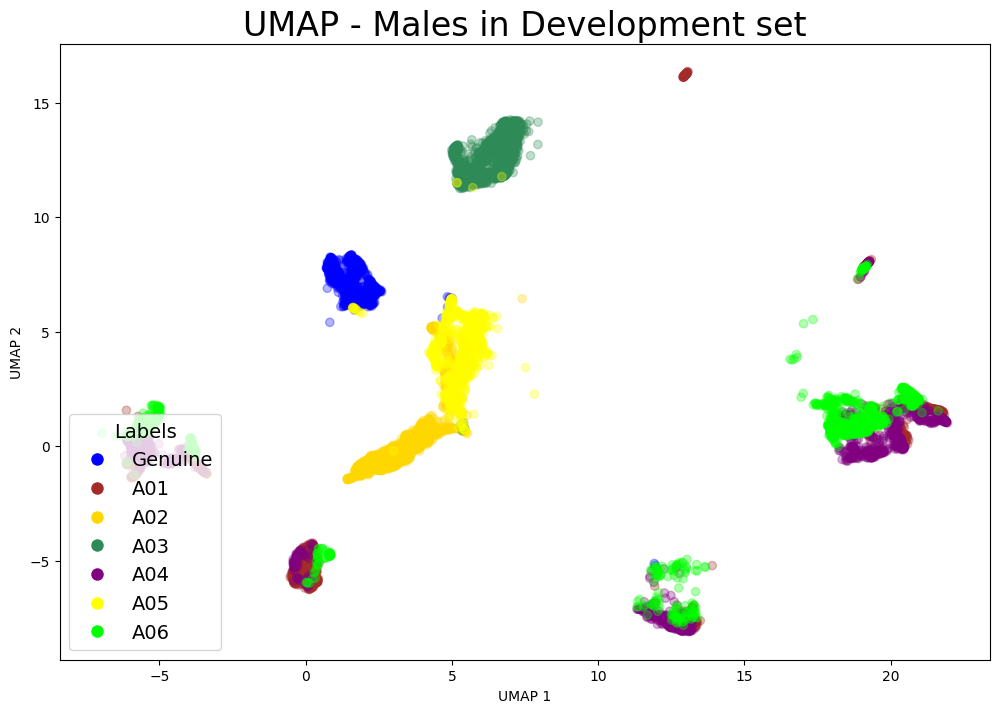

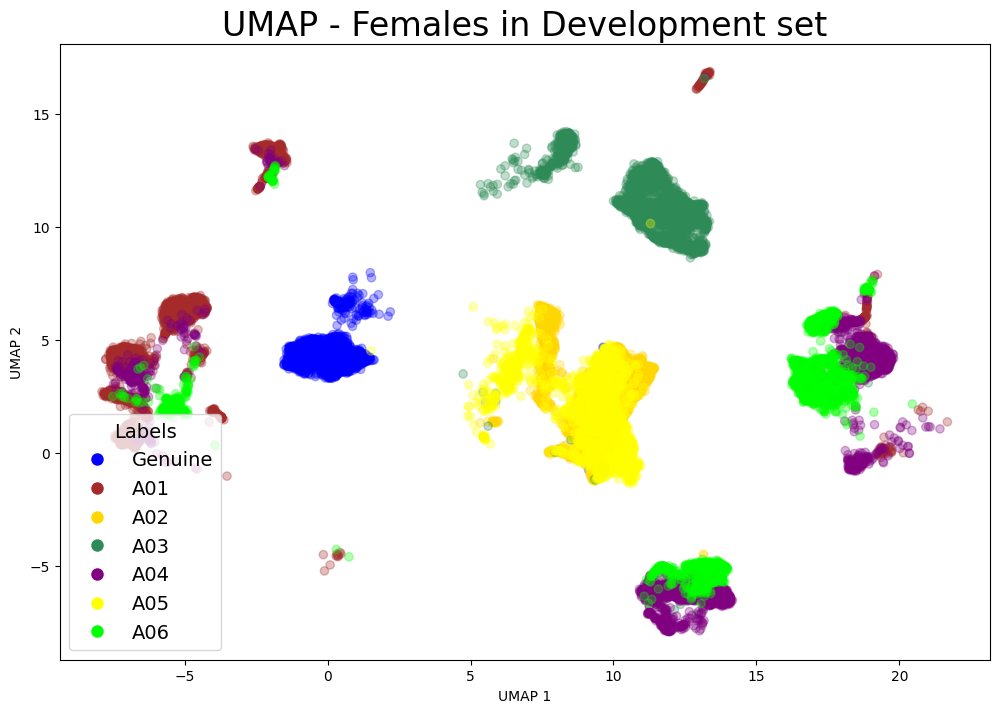

In [10]:
time_emb.plotting_vs_attacks_dev(plot_title = 'UMAP - Males in Development set',gender = 'male')
time_emb.plotting_vs_attacks_dev(plot_title = 'UMAP - Females in Development set',gender = 'female')

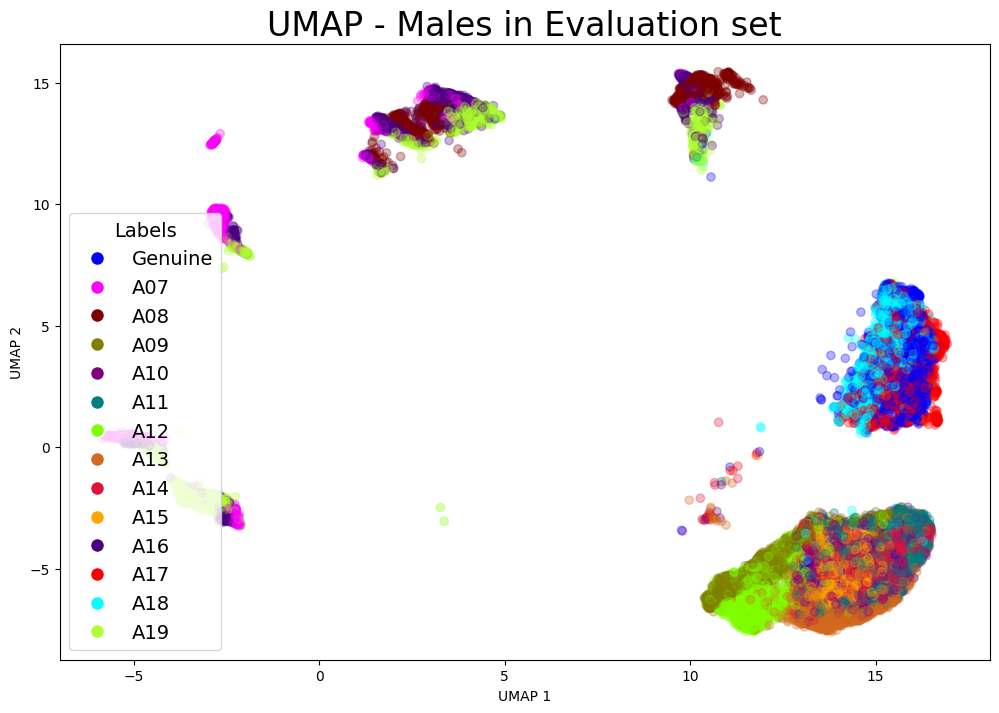

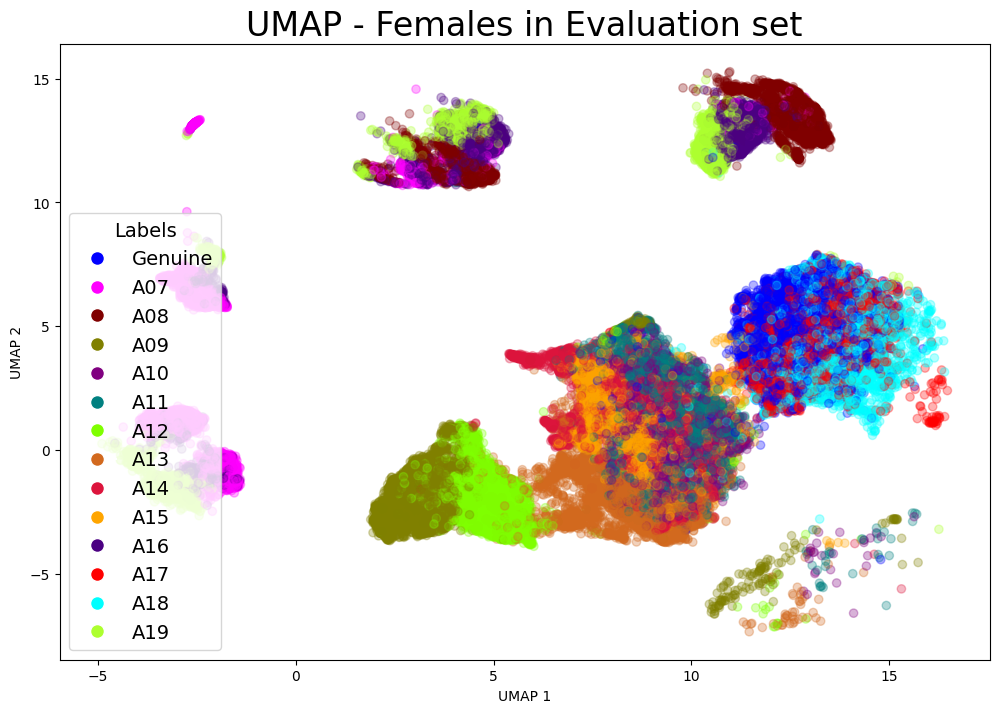

In [11]:
time_emb.plotting_vs_attacks_eval(plot_title = 'UMAP - Males in Evaluation set',gender = 'male')
time_emb.plotting_vs_attacks_eval(plot_title = 'UMAP - Females in Evaluation set',gender = 'female')

# t-SNE

In [ ]:
from sklearn.manifold import TSNE
class class_time_embeddings_t_sne:
    def __init__(self,path_to_male_embeddings, path_to_female_embeddings):
        self.path_to_male_embeddings = path_to_male_embeddings
        self.path_to_female_embeddings = path_to_female_embeddings
        
        (embedded_groups_1_1_male, embedded_groups_1_2_male, embedded_groups_1_3_male,
            chosen_labels_1_1_is_spoofed_male, chosen_labels_2_1_is_spoofed_male, chosen_labels_3_1_is_spoofed_male,
            chosen_labels_numeric_1_1_male, chosen_labels_numeric_2_1_male, chosen_labels_numeric_3_1_male,
            chosen_labels_1_1_attack_logical_male, chosen_labels_2_1_attack_logical_male, chosen_labels_3_1_attack_logical_male,
            chosen_labels_1_1_name_male, chosen_labels_2_1_name_male, chosen_labels_3_1_name_male,
            chosen_labels_1_1_speaker_id_male, chosen_labels_2_1_speaker_id_male, chosen_labels_3_1_speaker_id_male,
            chosen_labels_1_1_sex_male, chosen_labels_2_1_sex_male, chosen_labels_3_1_sex_male) = load_data_male(self.path_to_male_embeddings)

        (embedded_groups_1_1_female, embedded_groups_1_2_female, embedded_groups_1_3_female,
            chosen_labels_1_1_is_spoofed_female, chosen_labels_2_1_is_spoofed_female, chosen_labels_3_1_is_spoofed_female,
            chosen_labels_numeric_1_1_female, chosen_labels_numeric_2_1_female, chosen_labels_numeric_3_1_female,
            chosen_labels_1_1_attack_logical_female, chosen_labels_2_1_attack_logical_female, chosen_labels_3_1_attack_logical_female,
            chosen_labels_1_1_name_female, chosen_labels_2_1_name_female, chosen_labels_3_1_name_female,
            chosen_labels_1_1_speaker_id_female, chosen_labels_2_1_speaker_id_female, chosen_labels_3_1_speaker_id_female,
            chosen_labels_1_1_sex_female, chosen_labels_2_1_sex_female, chosen_labels_3_1_sex_female) = load_data_female(self.path_to_female_embeddings)

        # Stack male and female data
        self.embedded_groups_1_1 = np.vstack((embedded_groups_1_1_male, embedded_groups_1_1_female))
        self.embedded_groups_1_2 = np.vstack((embedded_groups_1_2_male, embedded_groups_1_2_female))
        self.embedded_groups_1_3 = np.vstack((embedded_groups_1_3_male, embedded_groups_1_3_female))

        self.chosen_labels_1_1_is_spoofed = np.hstack((chosen_labels_1_1_is_spoofed_male, chosen_labels_1_1_is_spoofed_female))
        self.chosen_labels_2_1_is_spoofed = np.hstack((chosen_labels_2_1_is_spoofed_male, chosen_labels_2_1_is_spoofed_female))
        self.chosen_labels_3_1_is_spoofed = np.hstack((chosen_labels_3_1_is_spoofed_male, chosen_labels_3_1_is_spoofed_female))

        self.chosen_labels_numeric_1_1 = np.hstack((chosen_labels_numeric_1_1_male, chosen_labels_numeric_1_1_female))
        self.chosen_labels_numeric_2_1 = np.hstack((chosen_labels_numeric_2_1_male, chosen_labels_numeric_2_1_female))
        self.chosen_labels_numeric_3_1 = np.hstack((chosen_labels_numeric_3_1_male, chosen_labels_numeric_3_1_female))

        self.chosen_labels_1_1_attack_logical = pd.concat([pd.Series(chosen_labels_1_1_attack_logical_male),
                                                           pd.Series(chosen_labels_1_1_attack_logical_female)])
        self.chosen_labels_2_1_attack_logical = pd.concat([pd.Series(chosen_labels_2_1_attack_logical_male),
                                                           pd.Series(chosen_labels_2_1_attack_logical_female)])
        self.chosen_labels_3_1_attack_logical = pd.concat([pd.Series(chosen_labels_3_1_attack_logical_male),
                                                           pd.Series(chosen_labels_3_1_attack_logical_female)])

        self.chosen_labels_1_1_name = np.hstack((chosen_labels_1_1_name_male, chosen_labels_1_1_name_female))
        self.chosen_labels_2_1_name = np.hstack((chosen_labels_2_1_name_male, chosen_labels_2_1_name_female))
        self.chosen_labels_3_1_name = np.hstack((chosen_labels_3_1_name_male, chosen_labels_3_1_name_female))

        self.chosen_labels_1_1_speaker_id = np.hstack((chosen_labels_1_1_speaker_id_male, chosen_labels_1_1_speaker_id_female))
        self.chosen_labels_2_1_speaker_id = np.hstack((chosen_labels_2_1_speaker_id_male, chosen_labels_2_1_speaker_id_female))
        self.chosen_labels_3_1_speaker_id = np.hstack((chosen_labels_3_1_speaker_id_male, chosen_labels_3_1_speaker_id_female))

        self.chosen_labels_1_1_sex = pd.concat([pd.Series(chosen_labels_1_1_sex_male), pd.Series(chosen_labels_1_1_sex_female)])
        self.chosen_labels_2_1_sex = pd.concat([pd.Series(chosen_labels_2_1_sex_male), pd.Series(chosen_labels_2_1_sex_female)])
        self.chosen_labels_3_1_sex = pd.concat([pd.Series(chosen_labels_3_1_sex_male), pd.Series(chosen_labels_3_1_sex_female)])
        
        
        self.train_embedding_pca = None
        self.dev_embedding_pca = None
        self.train_embedding_umap = None
        self.dev_embedding_umap = None
        
        self.chosen_labels_1_1_attack_logical = pd.Series([x[0] for x in self.chosen_labels_1_1_attack_logical]).replace('none', 'Genuine')
        
        self.chosen_labels_2_1_attack_logical = pd.Series([x[0] for x in self.chosen_labels_2_1_attack_logical]).replace('none', 'Genuine')
        
        self.chosen_labels_3_1_attack_logical = pd.Series([x[0] for x in self.chosen_labels_3_1_attack_logical]).replace('none', 'Genuine')
        
        self.chosen_labels_1_1_sex = pd.Series([x[0] for x in self.chosen_labels_1_1_sex])
        
        self.chosen_labels_2_1_sex = pd.Series([x[0] for x in self.chosen_labels_2_1_sex])
        
        self.chosen_labels_3_1_sex = pd.Series([x[0] for x in self.chosen_labels_3_1_sex])
        
        
        # Define unique labels including 'genuine'
        unique_labels = np.concatenate([self.chosen_labels_1_1_attack_logical.unique() , self.chosen_labels_2_1_attack_logical.unique()], axis=0)
        
        
        # Generate a colormap
         
            
        colors = np.array([
            "#A52A2A",  # Brown
            "#FFD700",  # Gold
            "#2E8B57",  # SeaGreen
            "#800080",  # Purple
            "#FFFF00",  # Yellow
            "#00FF00",  # Green
            "#FF00FF",  # Magenta
            "#800000",  # Maroon
            "#808000",  # Olive
            "#800080",  # Purple
            "#008080",  # Teal
            "#7FFF00",  # Chartreuse
            "#D2691E",  # Chocolate
            "#DC143C",  # Crimson
            "#4B0082",  # Indigo
            "#ADFF2F",  # GreenYellow
            "#FF4500",  # OrangeRed
        ])

        # Ensure uniqueness by removing duplicates (if needed)
        # colors = np.unique(colors, axis=0)

        # Map each unique label to a color
        labels = [f"A{str(i).zfill(2)}" for i in range(1, 20) if i not in [15, 17, 18]]

        # Add the 'none' label
        labels.append('Genuine')

        # Create the dictionary mapping labels to colors
        label_to_color = {label: color for label, color in zip(labels, colors)}

        # Explicitly set 'none' to BLUE color
        label_to_color['Genuine'] = "#0000FF" # Blue
        label_to_color['A18'] = "#00FFFF" # Cyan
        label_to_color['A17'] = "#FF0000" # Red
        label_to_color['A15'] = "#FFA500" # Orange
        

        # Select the keys to extract
        keys_to_extract = ['Genuine', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06']
        selected_colors_A01_A06 = {key: label_to_color[key] for key in keys_to_extract}

        
        keys_to_extract_2 = ['Genuine', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19']
        selected_colors_A01_A19 = {key: label_to_color[key] for key in keys_to_extract_2}

        
        self.label_to_color_1 = selected_colors_A01_A06
        
        self.labels_to_color_3 = selected_colors_A01_A19
        
        
        self.chosen_labels_1_1_attack_logical_mapping = self.chosen_labels_1_1_attack_logical.map(self.label_to_color_1)
       
        self.chosen_labels_2_1_attack_logical_mapping = self.chosen_labels_2_1_attack_logical.map(self.label_to_color_1)
        
        self.chosen_labels_3_1_attack_logical_mapping = self.chosen_labels_3_1_attack_logical.map(self.labels_to_color_3)
        
        self.frontsize = 14
        
    def create_t_sne(self,include_dev=False,include_eval=False):
        tsne = TSNE(n_components=2,n_jobs=-1)
        self.train_embedding_tsne = tsne.fit_transform(self.embedded_groups_1_1)
        
        if include_dev:
            tsne = TSNE(n_components=2,n_jobs=-1)
            self.dev_embedding_tsne = tsne.fit_transform(self.embedded_groups_1_2)
        
        if include_eval:
            tsne = TSNE(n_components=2,n_jobs=-1)
            self.eval_embedding_tsne = tsne.fit_transform(self.embedded_groups_1_3)
        
        return self.train_embedding_tsne ,self.dev_embedding_tsne,self.eval_embedding_tsne
        
      
    def plotting_train(self,plot_title='Train embeddings',gender = 'male'):
        
        fig, ax = plt.subplots(figsize=(12, 8))
        
         # Define color mapping for labels 0 and 1
        label_to_color = {0: 'green', 1: 'orange'}
        
        if gender == 'male':
            embeddings =  self.train_embedding_tsne[self.chosen_labels_1_1_sex == 'male']
        elif gender == 'female':
            embeddings =  self.train_embedding_tsne[self.chosen_labels_1_1_sex == 'female']
        
        # Convert labels to colors
        color_data = np.array([label_to_color[label] for label in self.chosen_labels_1_1_is_spoofed])
        
        ax.scatter(embeddings[:,0],embeddings[:,1],c=color_data,alpha = 0.3)
     
            
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for label, color in label_to_color.items()]
        labels = ['Genuine', 'Spoofed']
        # Add legend to the plot
        ax.legend(handles, labels, title="Labels",fontsize=self.frontsize,title_fontsize='14',loc='upper right')
        ax.set_title(plot_title, fontsize=24)
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('t-SNE 2')
   
        plt.show()
    
    def plotting_dev(self,plot_title='Dev embeddings',gender = 'male'):
        fig, ax = plt.subplots(figsize=(12, 8))
        label_to_color = {0: 'purple', 1: 'black'}
        color_data = np.array([label_to_color[label] for label in self.chosen_labels_2_1_is_spoofed])
        if gender == 'male':
            embeddings =  self.dev_embedding_tsne[self.chosen_labels_2_1_sex == 'male']
        elif gender == 'female':
            embeddings =  self.dev_embedding_tsne[self.chosen_labels_2_1_sex == 'female']
        
        ax.scatter(embeddings[:,0],embeddings[:,1],c=color_data,alpha = 0.3)
        
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for label, color in label_to_color.items()]
        labels = ['Genuine', 'Spoofed']
        # Add legend to the plot
        ax.legend(handles, labels, title="Labels",fontsize=self.frontsize,title_fontsize='14',loc='upper right')
        ax.set_title(plot_title, fontsize=24)
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('t-SNE 2')
        plt.show()
        
    def plotting_eval(self,plot_title='Eval embeddings',gender = 'male'):
        fig, ax = plt.subplots(figsize=(12, 8))
        label_to_color = {0: 'blue', 1: 'red'}
        color_data = np.array([label_to_color[label] for label in self.chosen_labels_3_1_is_spoofed])
        if gender == 'male':
            embeddings =  self.eval_embedding_tsne[self.chosen_labels_3_1_sex == 'male']
        elif gender == 'female':
            embeddings =  self.eval_embedding_tsne[self.chosen_labels_3_1_sex == 'female']
        
        ax.scatter(embeddings[:,0],embeddings[:,1],c=color_data,alpha = 0.3)
        
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for label, color in label_to_color.items()]
        labels = ['Genuine', 'Spoofed']
        # Add legend to the plot
        ax.legend(handles, labels, title="Labels",fontsize=self.frontsize,title_fontsize='16',loc='upper right')
        ax.set_title(plot_title, fontsize=24)
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('t-SNE 2')
        plt.show()
        
    def plotting_vs_attacks_train(self,plot_title='Train embeddings',gender = 'male'):
        fig, ax = plt.subplots(figsize=(12, 8))
        
        if gender == 'male':
            embeddings =  self.train_embedding_tsne[self.chosen_labels_1_1_sex == 'male']
            ax.scatter(embeddings[:,0],embeddings[:,1],c=self.chosen_labels_1_1_attack_logical_mapping[self.chosen_labels_1_1_sex == 'male'], alpha=0.3)
        elif gender == 'female':
            embeddings =  self.train_embedding_tsne[self.chosen_labels_1_1_sex == 'female']
            ax.scatter(embeddings[:,0],embeddings[:,1],c=self.chosen_labels_1_1_attack_logical_mapping[self.chosen_labels_1_1_sex == 'female'], alpha=0.3)
    
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for label, color in self.label_to_color_1.items()]
        labels = list(self.label_to_color_1.keys())
      
        ax.legend(handles, labels, title="Labels",fontsize=self.frontsize,title_fontsize='14',loc='upper right')
        ax.set_title(plot_title, fontsize=24)
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('t-SNE 2')
        plt.show()
        
    def plotting_vs_attacks_dev(self,plot_title='Dev embeddings',gender = 'male'):
        fig, ax = plt.subplots(figsize=(12, 8))
        if gender == 'male':
            embeddings =  self.dev_embedding_tsne[self.chosen_labels_2_1_sex == 'male']
            ax.scatter(embeddings[:,0],embeddings[:,1],c=self.chosen_labels_2_1_attack_logical_mapping[self.chosen_labels_2_1_sex == 'male'], alpha=0.3)
        elif gender == 'female':
            embeddings =  self.dev_embedding_tsne[self.chosen_labels_2_1_sex == 'female']
            ax.scatter(embeddings[:,0],embeddings[:,1],c=self.chosen_labels_2_1_attack_logical_mapping[self.chosen_labels_2_1_sex == 'female'], alpha=0.3)
    
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for label, color in self.label_to_color_1.items()]
        labels = list(self.label_to_color_1.keys())
        ax.legend(handles, labels, title="Labels",fontsize=self.frontsize,title_fontsize='14',loc='upper right')
        ax.set_title(plot_title, fontsize=24)
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('Ut-SNEMAP 2')
        plt.show()
        
    def plotting_vs_attacks_eval(self,plot_title='Eval embeddings',gender = 'male'):
        fig, ax = plt.subplots(figsize=(12, 8))
        if gender == 'male':
            embeddings =  self.eval_embedding_tsne[self.chosen_labels_3_1_sex == 'male']
            ax.scatter(embeddings[:,0],embeddings[:,1],c=self.chosen_labels_3_1_attack_logical_mapping[self.chosen_labels_3_1_sex == 'male'], alpha=0.3)
        elif gender == 'female':
            embeddings =  self.eval_embedding_tsne[self.chosen_labels_3_1_sex == 'female']
            ax.scatter(embeddings[:,0],embeddings[:,1],c=self.chosen_labels_3_1_attack_logical_mapping[self.chosen_labels_3_1_sex == 'female'], alpha=0.3)
    
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for label, color in self.labels_to_color_3.items()]
        labels = list(self.labels_to_color_3.keys())
 
        ax.legend(handles, labels, title="Labels",fontsize=self.frontsize,title_fontsize='14',loc='upper right')
        ax.set_title(plot_title, fontsize=24)
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('t-SNE 2')
        plt.show()
       
        

    
time_emb = class_time_embeddings_t_sne('./Data/pmf_both/not_normalize/male','./Data/pmf_both/not_normalize/female')


In [ ]:
train_embedding_tsne, dev__embedding_tsne, eval__embedding_tsne, = time_emb.create_t_sne(include_dev=True,include_eval=True)  

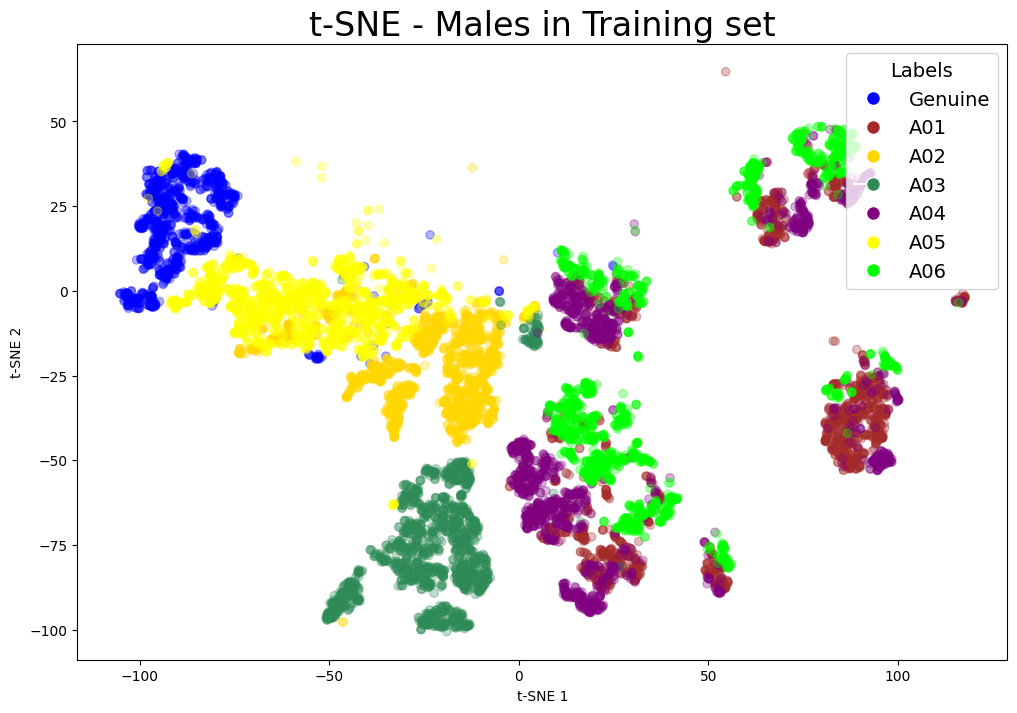

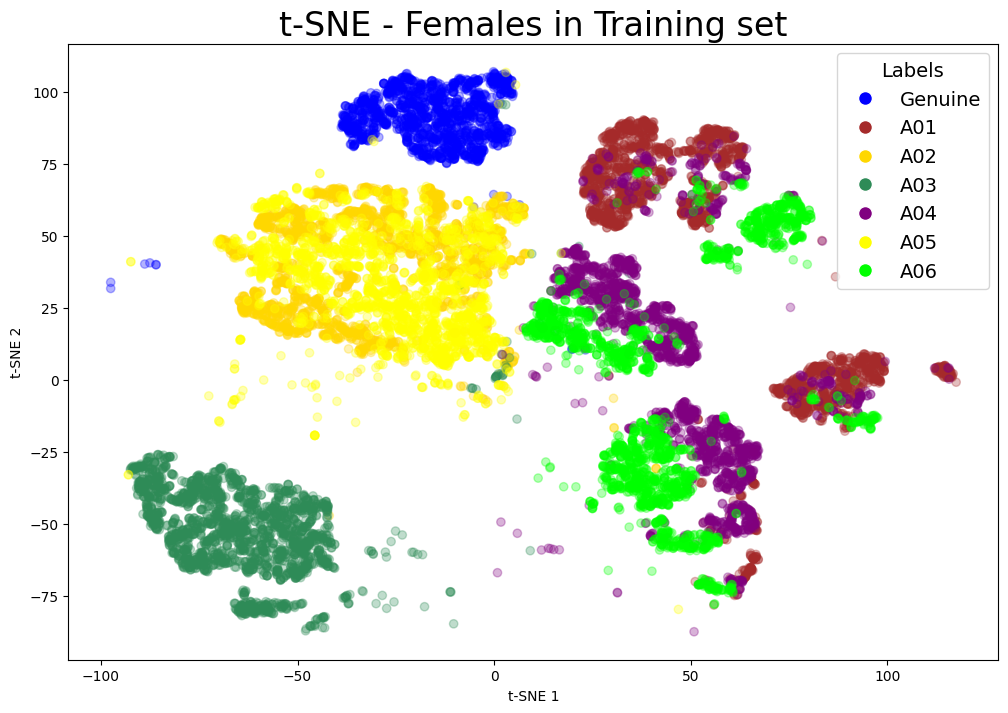

In [ ]:
time_emb.plotting_vs_attacks_train(plot_title = 't-SNE - Males in Training set',gender = 'male')
time_emb.plotting_vs_attacks_train(plot_title = 't-SNE - Females in Training set',gender = 'female')

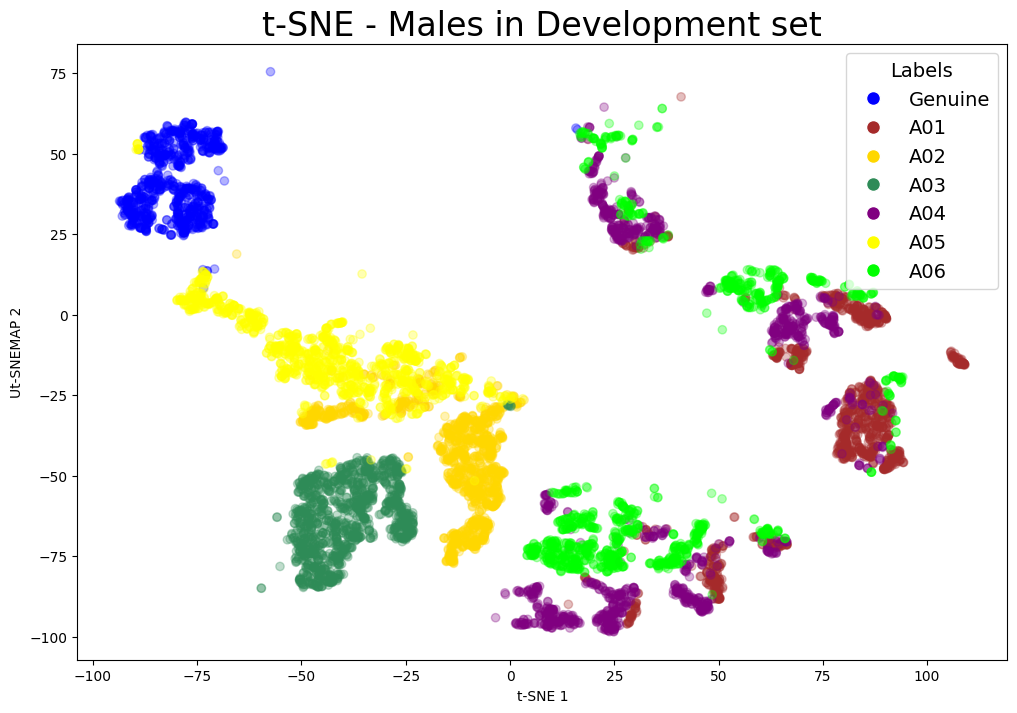

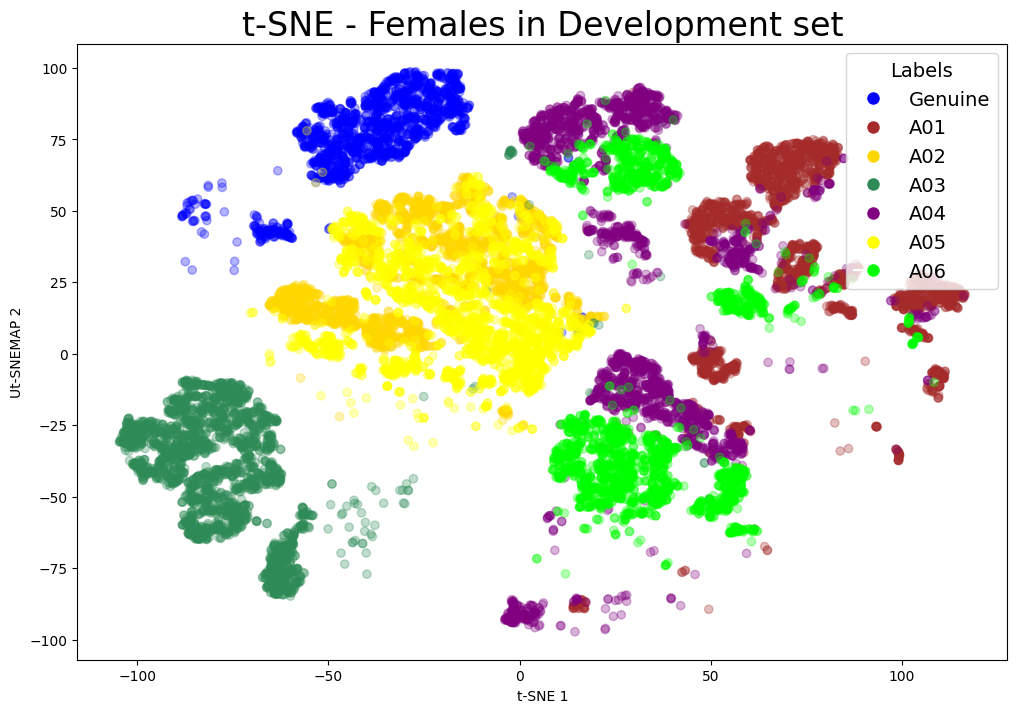

In [ ]:
time_emb.plotting_vs_attacks_dev(plot_title = 't-SNE - Males in Development set',gender = 'male')
time_emb.plotting_vs_attacks_dev(plot_title = 't-SNE - Females in Development set',gender = 'female')

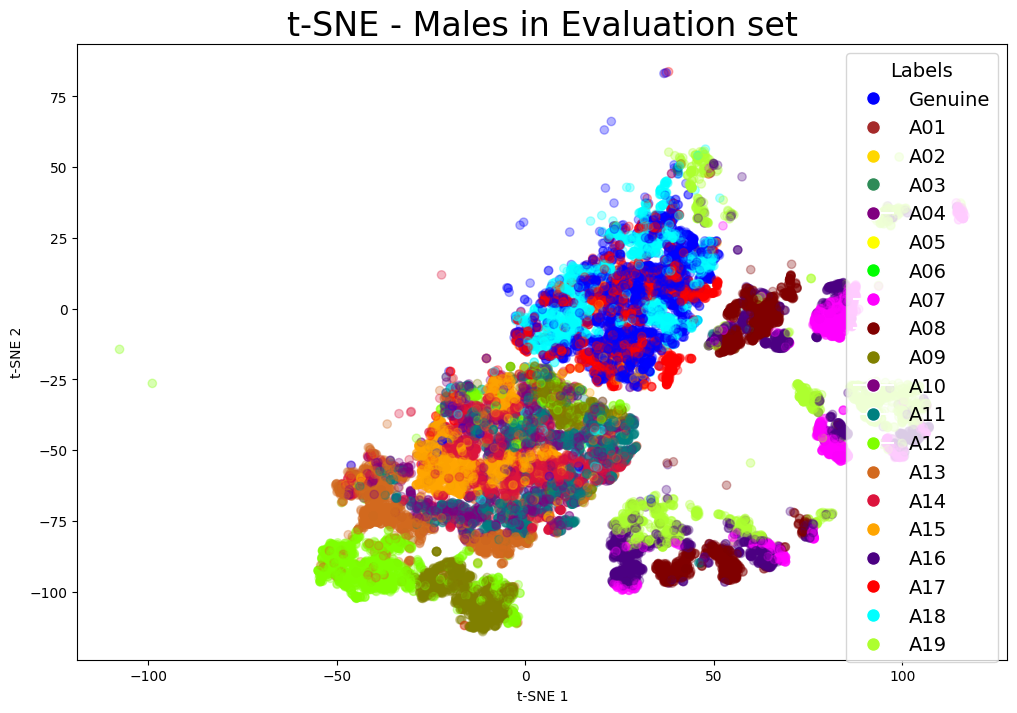

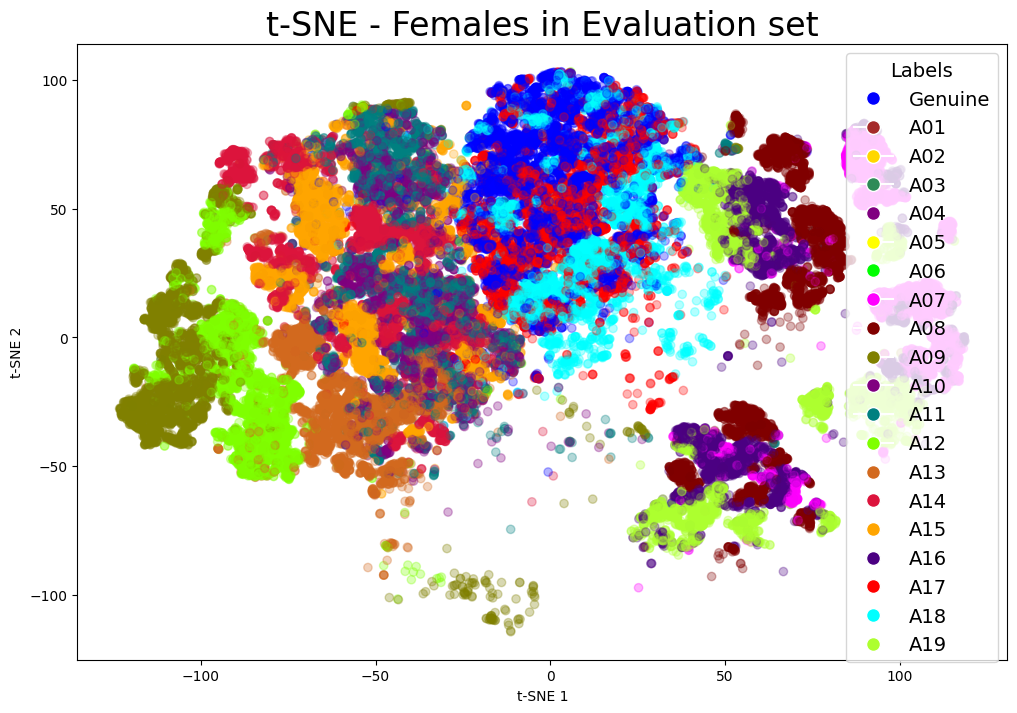

In [ ]:
time_emb.plotting_vs_attacks_eval(plot_title = 't-SNE - Males in Evaluation set',gender = 'male')
time_emb.plotting_vs_attacks_eval(plot_title = 't-SNE - Females in Evaluation set',gender = 'female')